#   LangGraph 활용 - 메시지 그래프 + 리듀서 구현 + 병렬 실행

---

## 환경 설정 및 준비

`(1) Env 환경변수`

In [146]:
from dotenv import load_dotenv
load_dotenv()

import os
from glob import glob

from pprint import pprint
import json

class ServiceState(TypedDict):
    user_question: str
    service_type: str
    sql_query: str
    search_results: List[str]
    final_answer: str

`(2) 기본 라이브러리`

In [ ]:
import os
from glob import glob
from pprint import pprint
import json
from typing import List, TypedDict





`(3) Langsmith tracing 설정`

In [3]:
# Langsmith tracing 여부를 확인 
import os
print(os.getenv('LANGSMITH_TRACING'))

true


## 서비스 분류 서비스 구현

### 함수 정의

<center>
<img src="https://raw.githubusercontent.com/tsdata/image_files/main/202505/query_rewrite.png" alt="rag" align="center" border="0"  width="800" height=auto>
</center>

In [ ]:
from typing import Literal
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

# LLM 인스턴스 생성
llm = ChatOpenAI(model="gpt-4.1-mini")

def chk_svc_typ(state: ServiceState) -> ServiceState:
    """ 사용자 입력이 질문 영역(제휴사/채널)에 대해 판단하는 함수 """

    # 사용자의 문의 영역을 분석하기 위한 템플릿
    analyze_template = """
    사용자 입력: {user_question}

    사용자의 입력이 제휴사 연동에 관한 질문인지 채널 연동에 관한 질문인지 판단하세요. 
    사용자의 입력의 키워드에 따라 분류가 가능합니다.
    - 제휴사 연동 키워드 : "고객", "사용자", "계약", "가입", "해지", "결제", "변경"
    - 채널 연동 키워드 : "오류", "조회"    

    제휴사 연동과 관련된 질문인 경우 "affiliate", 채널 연동과 관련된 질문인 경우 "channel"로 답변하세요.
    판단이 불가한 경우 "unknown"으로 답변하세요.

    답변:
    """

    # 사용자 입력을 분석하여 한국어인지 판단
    analyze_prompt = ChatPromptTemplate.from_template(analyze_template)
    analyze_chain = analyze_prompt | llm | StrOutputParser()
    result = analyze_chain.invoke({"user_question": state['user_question']})
    service_type = result.strip().lower()
    
    print ("SVC TYPE : ", service_type)
    # 결과를 상태에 업데이트 
    return {"service_type": service_type}


def decide_next_step(
        state: ServiceState
    ) -> Literal["aff_svc_qna", "chn_svc_qna", "revise_qna"]:#, "generate_response"]:
    """ 다음 실행 단계를 결정하는 함수 """

    # 한국어인 경우 한국어 문서 검색 함수 실행
    if state['service_type'] == "affiliate":
        return "aff_svc_qna"
    elif state['service_type'] == "channel":
        return "chn_svc_qna"
    else:
        return "revise_qna"  


def revise_qna(state: ServiceState) -> ServiceState:
    """ 사용자 입력이 질문 영역(제휴사/채널)을 판단하기 부족한 경우 입력 보완 방안을 제공하는 함수 """

    # 사용자의 문의 영역을 분석하기 위한 템플릿
    revise_templet = """
    사용자 입력: {user_question}
    사용자는 "제휴사(affiliate)" 연동 혹은 "채널(channel)" 연동에 대해 문의하고 있습니다. 
    사용자 입력에 다음 키워드가 존재하는 경우 사용자의 질문 영역을 판단할 수 있습니다.
    - 제휴사 연동 키워드 : "고객", "사용자", "계약", "가입", "해지", "결제", "변경"
    - 채널 연동 키워드 : "오류", "조회", "채널"

    사용자 입력에 키워드가 없거나 부족하여 질문 영역에 대한 판단이 불가하지 않도록 사용자 입력을 보완할 수 있는 방안을 제공하세요.
    
    답변:
    """

    # 사용자 입력을 보완할 방안을 제공
    analyze_prompt = ChatPromptTemplate.from_template(revise_templet)
    analyze_chain = analyze_prompt | llm | StrOutputParser()
    result = analyze_chain.invoke({"user_question": state['user_question']})
    final_answer = result.strip().lower()
    
    print ("FIN_ANS : ", final_answer)
    # 결과를 상태에 업데이트 
    return {"final_answer": final_answer}


def gen_res(state: ServiceState) -> ServiceState:
    """ 답변 생성 함수 """

    # 답변 템플릿
    response_template = """
    다음 정보를 바탕으로 사용자의 질문에 대한 답변을 생성하세요.
    검색 결과의 정보를 활용하여 정확하고 유용한 정보를 제공하세요.
    사용자 입력: {user_question}
    검색 결과: {search_results}

    답변:
    """

    # 답변 생성
    response_prompt = ChatPromptTemplate.from_template(response_template)
    response_chain = response_prompt | llm | StrOutputParser()
    
    final_answer = response_chain.invoke(
        {
            "user_question": state['user_question'],   # 사용자 입력 (상태에서 가져옴)
            "search_results": state['search_results'],  # 검색 결과 (상태에서 가져옴)
            #"language": "한국어" if state['qna_type'] else "영어" # 언어 정보
        }
    )
    
    # 결과를 상태에 저장
    return {"final_answer": final_answer}




## 채널 연동 서비스 처리

### 제휴사 연동 이력 DB 구성

### 제휴사 연동 서비스 구현

In [ ]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# 검색 및 벡터 저장
from langchain_chroma import Chroma
#from langchain.retrievers.multi_query import MultiQueryRetriever

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

def initialize_vector_store(embeddings = OpenAIEmbeddings(model="text-embedding-3-small"), collection_name="hybrid_search_db", persist_directory = "./local_chroma_db"):
    """
    기존 벡터 저장소를 로드하거나 새로 생성
    
    Returns:
        Chroma: 벡터 저장소 객체
    """
    try:
        
        # 기존 벡터 저장소 로드 시도
        #vector_store = Chroma(
        #    collection_name=collection_name,
        #    embedding_function=embeddings,
        #    persist_directory=persist_directory,
        #)

        vector_store = Chroma(
            collection_name="CHN_ERROR_LISTS",
            embedding_function=embeddings,
            persist_directory="./chroma_db_tuniverse",
        )
        
        doc_count = vector_store._collection.count()
        if doc_count > 0:
            print(f"✅ 기존 벡터 저장소 로드: {doc_count}개 문서")
            return vector_store
        else:
            print("⚠️ 빈 벡터 저장소입니다. 데이터를 추가해주세요.")
            return vector_store
            
    except Exception as e:
        print(f"벡터 저장소 로드 실패: {e}")
        return None

# 벡터 저장소 초기화
chroma_db = initialize_vector_store()

# 기본 retriever 초기화
chroma_k_retriever = chroma_db.as_retriever(
    search_kwargs={"k": 5}
)

query = "401오류의 해결방안?"
retrieved_docs = chroma_k_retriever.invoke(query)

for doc in retrieved_docs:
    print(f"{doc.page_content} [출처: {doc.metadata['source']}]")
    print("="*200)






⚠️ 빈 벡터 저장소입니다. 데이터를 추가해주세요.


## 제휴사 연동 서비스 처리


### 제휴사 연동 이력 DB 구성

In [64]:
import pandas as pd
import sqlite3

#로그 출력 여부
f_print_log = True

aff_hist_file = "data/PRJ_AFFC_HIST_KR_CSV.csv"

#df_qa_test = pd.read_excel("data/PRJ_AFFC_HIST_XLS.xls")
aff_hist_data = pd.read_csv(aff_hist_file)

print(f"load completed...FILE[{aff_hist_file}] CNT[{aff_hist_data.shape[0]}]")
aff_hist_data.head(2)
print("-"*80)

aff_hist_data.columns = ['연동일시', '고객번호', '고객명', '계약번호', '계약서비스번호', '제휴사명', '업무유형', '연동유형', '결과코드', '에러코드', '에러메시지', '요청전문', '응답전문', '상품ID', '상품명', '서비스ID', '서비스명']
# 데이터 타입 변환
def convert_to_numeric_safely(value):
    try:
        return pd.to_numeric(value)
    except:
        return None

def convert_to_datetime_safely(value):
    try:
        return pd.to_datetime(value)
    except:
        return None

# 각 컬럼의 데이터 타입 변환
aff_hist_data['연동일시'] = aff_hist_data['연동일시'].apply(convert_to_datetime_safely)
aff_hist_data['고객번호'] = aff_hist_data['고객번호'].apply(lambda x: str(x).strip())
aff_hist_data['계약번호'] = aff_hist_data['계약번호'].apply(lambda x: str(x).strip())
aff_hist_data['계약서비스번호'] = aff_hist_data['계약서비스번호'].apply(lambda x: str(x).strip())
aff_hist_data['제휴사명'] = aff_hist_data['제휴사명'].apply(lambda x: str(x).strip())
aff_hist_data['업무유형'] = aff_hist_data['업무유형'].apply(lambda x: str(x).strip())
aff_hist_data['연동유형'] = aff_hist_data['연동유형'].apply(lambda x: str(x).strip())
aff_hist_data['결과코드'] = aff_hist_data['결과코드'].apply(lambda x: str(x).strip())
aff_hist_data['에러코드'] = aff_hist_data['에러코드'].apply(lambda x: str(x).strip())
aff_hist_data['요청전문'] = aff_hist_data['요청전문'].apply(lambda x: str(x).strip())
aff_hist_data['응답전문'] = aff_hist_data['응답전문'].apply(lambda x: str(x).strip())
aff_hist_data['상품ID'] = aff_hist_data['상품ID'].apply(lambda x: str(x).strip())
aff_hist_data['상품명'] = aff_hist_data['상품명'].apply(lambda x: str(x).strip())
aff_hist_data['서비스ID'] = aff_hist_data['서비스ID'].apply(lambda x: str(x).strip())
aff_hist_data['서비스명'] = aff_hist_data['서비스명'].apply(lambda x: str(x).strip())


print("convert type of column completed...")
aff_hist_data.info()
print("-"*80)

DB_TUNIVERSE = 'tuniverse_integration_hist_database.db'
TABLE_TUNIVERSE_AFF_HIST = 'aff_if_hist'

# SQLite 데이터베이스 생성
conn = sqlite3.connect(DB_TUNIVERSE)
cursor = conn.cursor()

if f_print_log:
    print(f"connect database completed...DB[{DB_TUNIVERSE}]")
    print("-"*80)

# 테이블 삭제 (if exists)
cursor.execute(f"DROP TABLE IF EXISTS {TABLE_TUNIVERSE_AFF_HIST}")

# 테이블 생성
cursor.execute("""
CREATE TABLE aff_if_hist (
    연동일시 DATETIME,
    고객번호 TEXT,
    고객명 TEXT,
    계약번호 TEXT,
    계약서비스번호 TEXT,
    제휴사명 TEXT,
    업무유형 TEXT,
    연동유형 TEXT,
    결과코드 TEXT,
    에러코드 TEXT,
    에러메시지 TEXT,
    요청전문 TEXT,
    응답전문 TEXT,
    상품ID TEXT,
    상품명 TEXT,
    서비스ID TEXT,
    서비스명 TEXT
)
""")

if f_print_log:
    print(f"create table completed...TBL[{TABLE_TUNIVERSE_AFF_HIST}]")
    print("--- table info. ---")
    aff_hist_data.info()
    print("-"*80)

# 데이터 삽입
for _, row in aff_hist_data.iterrows():
    try:
        cursor.execute(f"""
        INSERT INTO {TABLE_TUNIVERSE_AFF_HIST} VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            str(row['연동일시']),
            str(row['고객번호']),
            str(row['고객명']),
            str(row['계약번호']),
            str(row['계약서비스번호']),
            str(row['제휴사명']),
            str(row['업무유형']),
            str(row['연동유형']),
            str(row['결과코드']),
            str(row['에러코드']),
            str(row['에러메시지']),
            str(row['요청전문']),
            str(row['응답전문']),
            str(row['상품ID']),
            str(row['상품명']),
            str(row['서비스ID']),
            str(row['서비스명'])
        ))
    except Exception as e:
        print(f"Error inserting row: {row}")
        print(f"Error message: {str(e)}")
        continue

# 변경사항 저장
conn.commit()

# 데이터베이스 상태 확인
cursor.execute("SELECT COUNT(*) FROM aff_if_hist")
aff_if_hist_count = cursor.fetchone()[0]

if f_print_log:
    print(f"insert table completed...TOT_CNT[{aff_if_hist_count}]")
    cursor.execute(f"SELECT * FROM {TABLE_TUNIVERSE_AFF_HIST} LIMIT 3")
    print("--- sample data ---")
    for fetch in cursor.fetchall():
        print("- ", fetch)
    print("-"*80)

#print("\n=== 데이터 샘플 ===")
#cursor.execute("SELECT * FROM aff_if_hist LIMIT 1")
#columns = [description[0] for description in cursor.description]
#row = cursor.fetchone()
#if row:
#    for col, val in zip(columns, row):
#        print(f"{col}: {val}")


load completed...FILE[data/PRJ_AFFC_HIST_KR_CSV.csv] CNT[121]
--------------------------------------------------------------------------------
convert type of column completed...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   연동일시     121 non-null    datetime64[ns]
 1   고객번호     121 non-null    object        
 2   고객명      121 non-null    object        
 3   계약번호     121 non-null    object        
 4   계약서비스번호  121 non-null    object        
 5   제휴사명     121 non-null    object        
 6   업무유형     121 non-null    object        
 7   연동유형     121 non-null    object        
 8   결과코드     121 non-null    object        
 9   에러코드     121 non-null    object        
 10  에러메시지    57 non-null     object        
 11  요청전문     121 non-null    object        
 12  응답전문     121 non-null    object        
 13  상품ID     121 non-null    object     

In [99]:
import pandas as pd
import sqlite3

#로그 출력 여부
f_print_log = True

aff_hist_file = "data/PRJ_AFFC_HIST_EN_CSV.csv"

#df_qa_test = pd.read_excel("data/PRJ_AFFC_HIST_XLS.xls")
aff_hist_data = pd.read_csv(aff_hist_file)

print(f"load completed...FILE[{aff_hist_file}] CNT[{aff_hist_data.shape[0]}]")
aff_hist_data.head(2)
print("-"*80)


aff_hist_data.columns = ['AUDIT_DTM', 'AUDIT_ID', 'MBR_NUM', 'MBR_NM', 'CTR_NUM', 'CTR_SVC_NUM', 'AFFC_BZR_NM', 'AFFC_LNKG_TSK_CD', 'AFFC_LNKG_TRMS_CD', 'TRMS_RSLT_CD', 'TRMS_ERR_CD', 'TRMS_ERR_MSG_CTT', 'TRMS_REQ_CNTT', 'TRMS_RES_CNTT', 'PRD_ID', 'PRD_NM', 'SKU_ID', 'SKU_NM']
# 데이터 타입 변환
def convert_to_numeric_safely(value):
    try:
        return pd.to_numeric(value)
    except:
        return None

def convert_to_datetime_safely(value):
    try:
        return pd.to_datetime(value)
    except:
        return None

#'AUDIT_DTM', 
#'AUDIT_ID', 
#'MBR_NUM', 
#'MBR_NM', 
#'CTR_NUM', 
#'CTR_SVC_NUM', 
#'AFFC_BZR_NM', 
#'AFFC_LNKG_TSK_CD', 
#'AFFC_LNKG_TRMS_CD', 
#'TRMS_RSLT_CD', 
#'TRMS_ERR_CD', 
#'TRMS_ERR_MSG_CTT', 
#'TRMS_REQ_CNTT', 
#'TRMS_RES_CNTT', 
#'PRD_ID', 
#'PRD_NM', 
#'SKU_ID', 
#'SKU_NM'
# 각 컬럼의 데이터 타입 변환
aff_hist_data['AUDIT_DTM'] = aff_hist_data['AUDIT_DTM'].apply(convert_to_datetime_safely)
aff_hist_data['AUDIT_ID'] = aff_hist_data['AUDIT_ID'].apply(lambda x: str(x).strip())
aff_hist_data['MBR_NUM'] = aff_hist_data['MBR_NUM'].apply(lambda x: str(x).strip())
aff_hist_data['MBR_NM'] = aff_hist_data['MBR_NM'].apply(lambda x: str(x).strip())
aff_hist_data['CTR_NUM'] = aff_hist_data['CTR_NUM'].apply(lambda x: str(x).strip())
aff_hist_data['CTR_SVC_NUM'] = aff_hist_data['CTR_SVC_NUM'].apply(lambda x: str(x).strip())
aff_hist_data['AFFC_BZR_NM'] = aff_hist_data['AFFC_BZR_NM'].apply(lambda x: str(x).strip())
aff_hist_data['AFFC_LNKG_TSK_CD'] = aff_hist_data['AFFC_LNKG_TSK_CD'].apply(lambda x: str(x).strip())
aff_hist_data['AFFC_LNKG_TRMS_CD'] = aff_hist_data['AFFC_LNKG_TRMS_CD'].apply(lambda x: str(x).strip())
aff_hist_data['TRMS_RSLT_CD'] = aff_hist_data['TRMS_RSLT_CD'].apply(lambda x: str(x).strip())
aff_hist_data['TRMS_ERR_CD'] = aff_hist_data['TRMS_ERR_CD'].apply(lambda x: str(x).strip())
aff_hist_data['TRMS_ERR_MSG_CTT'] = aff_hist_data['TRMS_ERR_MSG_CTT'].apply(lambda x: str(x).strip())
aff_hist_data['TRMS_REQ_CNTT'] = aff_hist_data['TRMS_REQ_CNTT'].apply(lambda x: str(x).strip())
aff_hist_data['TRMS_RES_CNTT'] = aff_hist_data['TRMS_RES_CNTT'].apply(lambda x: str(x).strip())
aff_hist_data['PRD_ID'] = aff_hist_data['PRD_ID'].apply(lambda x: str(x).strip())
aff_hist_data['PRD_NM'] = aff_hist_data['PRD_NM'].apply(lambda x: str(x).strip())
aff_hist_data['SKU_ID'] = aff_hist_data['SKU_ID'].apply(lambda x: str(x).strip())
aff_hist_data['SKU_NM'] = aff_hist_data['SKU_NM'].apply(lambda x: str(x).strip())

print("convert type of column completed...")
aff_hist_data.info()
print("-"*80)

DB_TUNIVERSE = 'tuniverse_integration_hist_database.db'
TABLE_TUNIVERSE_AFF_HIST = 'aff_if_hist'

# SQLite 데이터베이스 생성
conn = sqlite3.connect(DB_TUNIVERSE)
cursor = conn.cursor()

if f_print_log:
    print(f"connect database completed...DB[{DB_TUNIVERSE}]")
    print("-"*80)

# 테이블 삭제 (if exists)
cursor.execute(f"DROP TABLE IF EXISTS {TABLE_TUNIVERSE_AFF_HIST}")

# 테이블 생성
cursor.execute("""
CREATE TABLE aff_if_hist (
    AUDIT_DTM DATETIME,
    AUDIT_ID TEXT,
    MBR_NUM TEXT,
    MBR_NM TEXT,
    CTR_NUM TEXT,
    CTR_SVC_NUM TEXT,
    AFFC_BZR_NM TEXT,
    AFFC_LNKG_TSK_CD TEXT,
    AFFC_LNKG_TRMS_CD TEXT,
    TRMS_RSLT_CD TEXT,
    TRMS_ERR_CD TEXT,
    TRMS_ERR_MSG_CTT TEXT,
    TRMS_REQ_CNTT TEXT,
    TRMS_RES_CNTT TEXT,
    PRD_ID TEXT,
    PRD_NM TEXT,
    SKU_ID TEXT,
    SKU_NM TEXT
)
""")

if f_print_log:
    print(f"create table completed...TBL[{TABLE_TUNIVERSE_AFF_HIST}]")
    print("--- table info. ---")
    aff_hist_data.info()
    print("-"*80)

# 데이터 삽입
for _, row in aff_hist_data.iterrows():
    try:
        cursor.execute(f"""
        INSERT INTO {TABLE_TUNIVERSE_AFF_HIST} VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            str(row['AUDIT_DTM']),
            str(row['AUDIT_ID']),
            str(row['MBR_NUM']),
            str(row['MBR_NM']),
            str(row['CTR_NUM']),
            str(row['CTR_SVC_NUM']),
            str(row['AFFC_BZR_NM']),
            str(row['AFFC_LNKG_TSK_CD']),
            str(row['AFFC_LNKG_TRMS_CD']),
            str(row['TRMS_RSLT_CD']),
            str(row['TRMS_ERR_CD']),
            str(row['TRMS_ERR_MSG_CTT']),
            str(row['TRMS_REQ_CNTT']),
            str(row['TRMS_RES_CNTT']),
            str(row['PRD_ID']),
            str(row['PRD_NM']),
            str(row['SKU_ID']),
            str(row['SKU_NM'])
        ))
    except Exception as e:
        print(f"Error inserting row: {row}")
        print(f"Error message: {str(e)}")
        continue

# 변경사항 저장
conn.commit()

# 데이터베이스 상태 확인
cursor.execute("SELECT COUNT(*) FROM aff_if_hist")
aff_if_hist_count = cursor.fetchone()[0]

if f_print_log:
    print(f"insert table completed...TOT_CNT[{aff_if_hist_count}]")
    cursor.execute(f"SELECT * FROM {TABLE_TUNIVERSE_AFF_HIST} LIMIT 3")
    print("--- sample data ---")
    for fetch in cursor.fetchall():
        print("- ", fetch)
    print("-"*80)

load completed...FILE[data/PRJ_AFFC_HIST_EN_CSV.csv] CNT[148]
--------------------------------------------------------------------------------
convert type of column completed...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   AUDIT_DTM          148 non-null    datetime64[ns]
 1   AUDIT_ID           148 non-null    object        
 2   MBR_NUM            148 non-null    object        
 3   MBR_NM             148 non-null    object        
 4   CTR_NUM            148 non-null    object        
 5   CTR_SVC_NUM        148 non-null    object        
 6   AFFC_BZR_NM        148 non-null    object        
 7   AFFC_LNKG_TSK_CD   148 non-null    object        
 8   AFFC_LNKG_TRMS_CD  148 non-null    object        
 9   TRMS_RSLT_CD       148 non-null    object        
 10  TRMS_ERR_CD        148 non-null    object        
 

## 제휴사 연동 서비스 처리 구현

In [129]:
from typing import List, TypedDict
from langchain_community.utilities import SQLDatabase
from langchain_openai import ChatOpenAI
from langchain.chains import create_sql_query_chain
from langchain_core.prompts import ChatPromptTemplate

#로그 출력 여부
f_print_log = True

query_prompt_template = ChatPromptTemplate.from_messages([
    ("system", 
    """
    당신은 SQL 데이터베이스와 상호작용하도록 설계된 에이전트입니다.
    입력된 질문을 기반으로 구문적으로 올바른 {dialect} 쿼리를 작성하고 실행한 뒤, 실행 결과를 답변으로 반환해야 합니다.
    
    입력된 질문으로 쿼리를 작성할 때에는 반드시 아래에서 제공하는 컬럼명과 컬럼값에 의미와 참고사항을 고려하여 작성해야 합니다.
    "-" 기호 뒤에 나오는 값은 테이블의 컬럼명과 그 의미와 참고사항입니다. (예시 : - 컬럼명 : 의미 - 참고사항)
    "---" 기호는 바로 위 컬럼의 값으로 등장할 수 있는 값과 그 의미입니다. (예시 : --- 컬럼값 : 의미 - 참고사항)
    - AUDIT_DTM : 연동이력 발생일시
    - AUDIT_ID : 처리자ID
    - MBR_NUM : 고객번호
    - MBR_NM : 고객명
    - CTR_NUM : 계약번호
    - CTR_SVC_NUM : 계약서비스번호
    - AFFC_BZR_NM : 제휴사명 - 상품을 제공하는 회사명으로 고객이 인지하는 정보와 정확하게 일치하지 않을 수 있으니 유사한 값으로 조회 필요
    - AFFC_LNKG_TSK_CD : 업무유형
    --- Q2 : 자동인증가능여부조회
    --- A1 : 가입준비
    --- A2 : 가입
    --- Q3 : 해지가능여부조회
    --- Z1 : 해지
    --- Z3 : 해지취소
    --- CO : 계약연장
    --- CN : 연장취소
    - AFFC_LNKG_TRMS_CD : 연동유형
    --- SB_RQ : T우주 처리 요청
    --- SB_RS : T우주 처리 결과 응답
    --- BS_RQ : 제휴사 처리 요청
    --- BS_RS : 제휴사 처리 결과 응답
    --- BS_AF : 제휴사 처리 결과 T우주 내부 전달
    - TRMS_RSLT_CD : 결과코드
    --- S : 성공
    --- F : 실패
    - TRMS_ERR_CD : 에러코드
    - TRMS_ERR_MSG_CTT : 에러메시지
    - TRMS_REQ_CNTT : 요청전문 - 요청에 사용된 JSON 형태의 전문
    - TRMS_RES_CNTT : 응답전문 - 요청에 대한 응답으로 사용된 JSON 형태의 전문
    - PRD_ID : 패키지ID - 실제 고객이 사용하는 단위 상품들의 묶음 상품의 ID로 10자리 문자열(PR로 시작)로 조회시 정확하게 일치해야 함
    - PRD_NM : 패키지명 - 계약번호와 연결되는 실제 고객이 사용하는 단위 상품들의 묶음 상품명(패키지 상품명)으로 고객이 인지하는 정보와 정확하게 일치하지 않을 수 있으니 유사한 값으로 조회 필요
    - SKU_ID : 상품ID - 실제 고객이 사용하는 단위 상품의 ID로 10자리 문자열(SU로 시작)로 조회시 정확하게 일치해야 함
    - SKU_NM : 상품명 - 계약서비스번호와 매핑되는 실제 고객이 사용하는 단위 상품명으로 고객이 인지하는 정보와 정확하게 일치하지 않을 수 있으니 유사한 값으로 조회 필요

    반환되는 결과의 컬럼명이나 컬럼의 값이 제공된 실제 의미로 대체 가능한 경우 해당 값을 대체하여 결과를 반환해야 합니다.
    
    작업을 시작할 때는 항상 데이터베이스의 테이블 목록을 확인해야 합니다.
    이 단계를 건너뛰지 마십시오.
    {table_info}
    """),
    ("user", 
    """
    Question:
    {query}
    """)
])

# 프롬프트 템플릿 출력
for m in query_prompt_template.messages:
   m.pretty_print()

query_prompt_template.input_schema.model_json_schema()

# state 스키마 
class ServiceState(TypedDict):
    user_question: str
    sql_query: str
    service_type: str
    search_results: List[str]
    final_answer: str

# SQLite 데이터베이스 연결
db = SQLDatabase.from_uri(f"sqlite:///{DB_TUNIVERSE}")

if f_print_log:
    print(f"conect database...DB[{DB_TUNIVERSE}]")
    # 사용 가능한 테이블 목록 출력
    print("--- table list ---")
    tables = db.get_usable_table_names()
    for table in tables:
        print("- ",table)
    print("-"*80)

state = ServiceState(
    user_question="카리나 고객이 가입한 밀리의서재 제휴사와 관련된 연동 이력을 보여줘",
    sql_query="",
    service_type="affiliate",
    search_results=[],
    final_answer=""
)

# SQL Chain 설정
#gpt_llm = ChatOpenAI(model="gpt-4.1-mini")
gpt_llm = ChatOpenAI(model="gpt-4.1")
gpt_sql = create_sql_query_chain(llm=gpt_llm, db=db)

# 쿼리 실행
#test_question = state['user_question']
#gpt_generated_sql = gpt_sql.invoke({'question':test_question})
#print(f"Answer (GPT):\n{gpt_generated_sql}")
#print("-"*100)

from typing import Annotated, TypedDict
from langchain_core.prompts import ChatPromptTemplate
from typing_extensions import TypedDict, Annotated

class QueryOutput(TypedDict):
    """Generated SQL query."""
    query: Annotated[str, ..., "Syntactically valid SQL query."]
    result: Annotated[str, ..., "Result of the query."]


"""Generate SQL query to fetch information."""
prompt = query_prompt_template.invoke(
    {
        "query": state["user_question"],
        "dialect": db.dialect,
        "table_info": db.get_table_info(),
    }
)
print("!!! prompt : ", prompt)
structured_llm = gpt_llm.with_structured_output(QueryOutput)
#state["sql_query"] = structured_llm.invoke(prompt)
#print ("결과과 왜 쿼리인가?...", state["sql_query"])


result = structured_llm.invoke(prompt)

print(f"RES_QRY[{result["query"]}]")
print(f"RES_RSLT[{result["result"]}]")

from langchain_community.tools import QuerySQLDatabaseTool

execute_query_tool = QuerySQLDatabaseTool(db=db)
state["search_results"] = execute_query_tool.invoke(state["sql_query"])

print(state["search_results"])




def aff_svc_qna(state: ServiceState) -> ServiceState:
    """ 제휴사 연동 Q&A 답변 """

    return {"search_results": ["교촌치킨", "메가커피", "뚜레주르"]}

    # 3개의 검색 결과를 가져옴
    results = db_english.similarity_search(state['user_question'], k=3)

    # 페이지 내용만 추출
    search_results = [doc.page_content for doc in results]

    # 검색 결과를 상태에 저장
    return {"search_results": search_results}

================================ System Message ================================


    당신은 SQL 데이터베이스와 상호작용하도록 설계된 에이전트입니다.
    입력된 질문을 기반으로 구문적으로 올바른 {dialect} 쿼리를 작성하고 실행한 뒤, 실행 결과를 답변으로 반환해야 합니다.

    입력된 질문으로 쿼리를 작성할 때에는 반드시 아래에서 제공하는 컬럼명과 컬럼값에 의미와 참고사항을 고려하여 작성해야 합니다.
    "-" 기호 뒤에 나오는 값은 테이블의 컬럼명과 그 의미와 참고사항입니다. (예시 : - 컬럼명 : 의미 - 참고사항)
    "---" 기호는 바로 위 컬럼의 값으로 등장할 수 있는 값과 그 의미입니다. (예시 : --- 컬럼값 : 의미 - 참고사항)
    - AUDIT_DTM : 연동이력 발생일시
    - AUDIT_ID : 처리자ID
    - MBR_NUM : 고객번호
    - MBR_NM : 고객명
    - CTR_NUM : 계약번호
    - CTR_SVC_NUM : 계약서비스번호
    - AFFC_BZR_NM : 제휴사명 - 상품을 제공하는 회사명으로 고객이 인지하는 정보와 정확하게 일치하지 않을 수 있으니 유사한 값으로 조회 필요
    - AFFC_LNKG_TSK_CD : 업무유형
    --- Q2 : 자동인증가능여부조회
    --- A1 : 가입준비
    --- A2 : 가입
    --- Q3 : 해지가능여부조회
    --- Z1 : 해지
    --- Z3 : 해지취소
    --- CO : 계약연장
    --- CN : 연장취소
    - AFFC_LNKG_TRMS_CD : 연동유형
    --- SB_RQ : T우주 처리 요청
    --- SB_RS : T우주 처리 결과 응답
    --- BS_RQ : 제휴사 처리 요청
    --- BS_RS : 제휴사 처리 결과 응답
    --- BS_AF : 제휴사 처리 결과 T우주 내

---

## 전체 서비스 처리를 위한 그래프 구현



In [144]:
from typing import List, TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from IPython.display import Image, display

# LLM 인스턴스 생성
llm = ChatOpenAI(model="gpt-4.1-mini")

# state 스키마 
class ServiceState(TypedDict):
    user_question: str
    service_type: str
    search_results: List[str]
    final_answer: str

def chn_svc_qna(state: ServiceState) -> ServiceState:
    """ 채널 연동 Q&A 답변 """

    return {"search_results": ["401", "500", "503"]}


def aff_svc_qna(state: ServiceState) -> ServiceState:
    """ 제휴사 연동 Q&A 답변 """

    return {"search_results": ["교촌치킨", "메가커피", "뚜레주르"]}

   
# 그래프 구성
builder = StateGraph(ServiceState)

# 노드 추가: 입력 분석, 한국어 문서 검색, 영어 문서 검색, 답변 생성
builder.add_node("chk_svc_typ", chk_svc_typ)
builder.add_node("aff_svc_qna", aff_svc_qna)
builder.add_node("chn_svc_qna", chn_svc_qna)
builder.add_node("revise_qna", revise_qna)
builder.add_node("gen_res", gen_res)

# 엣지 추가: 시작 -> 사용자 입력 분석 -> 조건부 엣지 -> 한국어 문서 검색 또는 영어 문서 검색 -> 답변 생성 -> 끝
builder.add_edge(START, "chk_svc_typ")

# 조건부 엣지 추가
builder.add_conditional_edges(
    "chk_svc_typ",
    decide_next_step
)

#builder.add_edge("analyze_service_type", "generate_response")
builder.add_edge("aff_svc_qna", "gen_res")
builder.add_edge("chn_svc_qna", "gen_res")
builder.add_edge("revise_qna", END)
builder.add_edge("gen_res", END)

# 그래프 컴파일
graph = builder.compile()

# 그래프 시각화
#display(Image(graph.get_graph().draw_mermaid_png()))



In [145]:
# 초기 상태
initial_state = {'user_question':'뭔가 잘 안되는데 왜 그런가요?'}

# 그래프 실행
result = graph.invoke(initial_state)

# 결과 출력
print("\n=== 결과 ===")
print("사용자 입력:", initial_state['user_question'])
print("답변:", result['final_answer'])

SVC TYPE :  unknown
FIN_ANS :  답변:  
사용자 입력에 관련 키워드가 명확하지 않거나 부족할 경우, 사용자가 문의하는 연동 영역을 파악하기 어려워 정확한 안내가 어렵습니다.  
따라서, 다음과 같은 방법으로 사용자 입력을 보완하도록 안내할 수 있습니다.

1. 구체적인 상황 또는 문제를 덧붙이게 유도하기  
   - 예시: "어떤 작업을 하다가 문제가 생겼나요?"  
   - 예시: "고객 정보나 계약 관련 문제인지, 아니면 채널 조회나 오류 발생 관련 문제인지 알려주세요."

2. 관련 키워드를 포함한 상세 질문 요청  
   - 제휴사 연동 관련: "결제나 계약 변경, 가입/해지 관련 문제인지 구체적으로 말씀해 주세요."  
   - 채널 연동 관련: "채널 조회, 오류 메시지 발생 등 상황을 상세히 알려 주세요."

3. 구체적인 증상이나 오류 메시지 요청  
   - "어떤 오류가 떴는지 메시지나 증상을 알려주시면 더 정확히 도와드릴 수 있습니다."

이와 같이 사용자로 하여금 자신의 상황을 좀 더 상세하고 명확하게 표현하도록 유도하면, 제휴사 연동인지 채널 연동인지 쉽게 파악할 수 있고, 보다 정확한 답변을 제공할 수 있습니다.

=== 결과 ===
사용자 입력: 뭔가 잘 안되는데 왜 그런가요?
답변: 답변:  
사용자 입력에 관련 키워드가 명확하지 않거나 부족할 경우, 사용자가 문의하는 연동 영역을 파악하기 어려워 정확한 안내가 어렵습니다.  
따라서, 다음과 같은 방법으로 사용자 입력을 보완하도록 안내할 수 있습니다.

1. 구체적인 상황 또는 문제를 덧붙이게 유도하기  
   - 예시: "어떤 작업을 하다가 문제가 생겼나요?"  
   - 예시: "고객 정보나 계약 관련 문제인지, 아니면 채널 조회나 오류 발생 관련 문제인지 알려주세요."

2. 관련 키워드를 포함한 상세 질문 요청  
   - 제휴사 연동 관련: "결제나 계약 변경, 가입/해지 관련 문제인지 구체적으로 말씀해 주세요."  
   - 채널 연동 관련: "

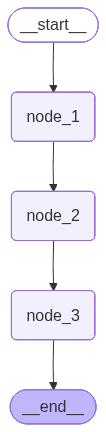

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 상태 정의 
class DocumentState(TypedDict):
    query: str
    documents: List[str]

# Node 1: query 업데이트
#def node_1(state: DocumentState) -> DocumentState:
#    print("---Node 1 (query update)---")
#    query = state["query"]
#    return {"query": query}

def CheckQnAType(state: DocumentState) -> DocumentState:
    print("---Node 1 (query update)---")
    query = state["query"]
    return {"query": query}

# Node 2: 검색된 문서 추가 
#def node_2(state: DocumentState) -> DocumentState:
#    print("---Node 2 (add documents)---")
#    return {"documents": ["doc1.pdf", "doc2.pdf", "doc3.pdf"]}
def ChannelIntegrationQnA(state: DocumentState) -> DocumentState:
    print("---Node 1 (query update)---")
    query = state["query"]
    return {"documents": ["401", "500", "503"]}

# Node 3: 추가적인 문서 검색 결과 추가
#def node_3(state: DocumentState) -> DocumentState:
#    print("---Node 3 (add more documents)---")
#    return {"documents": ["doc2.pdf", "doc4.pdf", "doc5.pdf"]}

def AffiliateIntegrationQnA(state: DocumentState) -> DocumentState:
    print("---Node 1 (query update)---")
    query = state["query"]
    return {"documents": ["교촌치킨", "메가커피", "뚜레주르"]}


# 그래프 빌드
builder = StateGraph(DocumentState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 논리 구성
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

# 그래프 실행
graph = builder.compile()

# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))


In [5]:
# 초기 상태
initial_state = {"query": "문서를 검색해주세요."}

# 그래프 실행 
final_state = graph.invoke(initial_state)

# 최종 상태 출력
print("-"*100)
print("최종 상태:")
print("쿼리:", final_state['query'])
print("검색된 문서:", final_state['documents'])

---Node 1 (query update)---
---Node 2 (add documents)---
---Node 3 (add more documents)---
----------------------------------------------------------------------------------------------------
최종 상태:
쿼리: 문서를 검색해주세요.
검색된 문서: ['doc2.pdf', 'doc4.pdf', 'doc5.pdf']


`(2) Reducer를 별도로 지정하는 경우 `

- **Annotated**를 통해 **사용자 정의 Reducer**를 지정할 수 있음 
- **operator.add**를 사용하면 리스트 형태의 데이터를 **누적 관리**할 수 있음 
- 여기서는 기존 리스트에 새로운 메시지를 추가하는 방식으로 작동

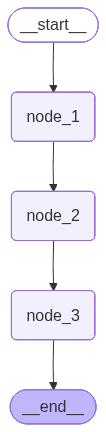

In [7]:
from operator import add
from typing import Annotated, TypedDict

class ReducerState(TypedDict):
    query: str
    documents: Annotated[List[str], add]

# Node 1: query 업데이트
def node_1(state: ReducerState) -> ReducerState:
    print("---Node 1 (query update)---")
    query = state["query"]
    return {"query": query}

# Node 2: 검색된 문서 추가 
def node_2(state: ReducerState) -> ReducerState:
    print("---Node 2 (add documents)---")
    return {"documents": ["doc1.pdf", "doc2.pdf", "doc3.pdf"]}

# Node 3: 추가적인 문서 검색 결과 추가
def node_3(state: ReducerState) -> ReducerState:
    print("---Node 3 (add more documents)---")
    return {"documents": ["doc2.pdf", "doc4.pdf", "doc5.pdf"]}

# 그래프 빌드
builder = StateGraph(ReducerState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 논리 구성
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

# 그래프 실행
graph = builder.compile()

# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
# 초기 상태
initial_state = {"query": "문서를 누적해서 검색해주세요."}

# 그래프 실행 
final_state = graph.invoke(initial_state)

# 최종 상태 출력
print("-"*100)
print("최종 상태:")
print("쿼리:", final_state['query'])
print("검색된 문서:", final_state['documents'])

---Node 1 (query update)---
---Node 2 (add documents)---
---Node 3 (add more documents)---
----------------------------------------------------------------------------------------------------
최종 상태:
쿼리: 문서를 누적해서 검색해주세요.
검색된 문서: ['doc1.pdf', 'doc2.pdf', 'doc3.pdf', 'doc2.pdf', 'doc4.pdf', 'doc5.pdf']


`(3) Custom Reducer 사용 `

- **Custom Reducer**는 **복잡한 상태 관리**가 필요할 때 사용됨 
- **중복 제거**나 **최대/최소값 유지**와 같은 특수한 로직을 구현할 수 있음 
- 비즈니스 요구사항에 맞는 **맞춤형 상태 관리**가 가능
- 상황에 따라 **조건부 병합**과 같은 고급 기능을 구현할 수 있음 

In [9]:
from typing import TypedDict, List, Annotated

# Custom reducer: 중복된 문서를 제거하며 리스트 병합
def reduce_unique_documents(left: list | None, right: list | None) -> list:
    """Combine two lists of documents, removing duplicates."""
    if not left:
        left = []
    if not right:
        right = []
    # 중복 제거: set을 사용하여 중복된 문서를 제거하고 다시 list로 변환
    return list(set(left + right))

# 상태 정의 (documents 필드 포함)
class CustomReducerState(TypedDict):
    query: str
    documents: Annotated[List[str], reduce_unique_documents]  # Custom Reducer 적용

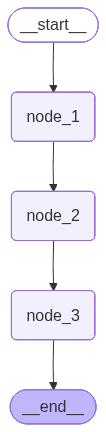

In [10]:
# Node 1: query 업데이트
def node_1(state: CustomReducerState) -> CustomReducerState:
    print("---Node 1 (query update)---")
    query = state["query"]
    return {"query": query}

# Node 2: 검색된 문서 추가 
def node_2(state: CustomReducerState) -> CustomReducerState:
    print("---Node 2 (add documents)---")
    return {"documents": ["doc1.pdf", "doc2.pdf", "doc3.pdf"]}

# Node 3: 추가적인 문서 검색 결과 추가
def node_3(state: CustomReducerState) -> CustomReducerState:
    print("---Node 3 (add more documents)---")
    return {"documents": ["doc2.pdf", "doc4.pdf", "doc5.pdf"]}

# 그래프 빌드
builder = StateGraph(CustomReducerState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 논리 구성
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

# 그래프 실행
graph = builder.compile()

# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
# 초기 상태
initial_state = {"query": "문서를 누적해서 검색해주세요."}

# 그래프 실행 
final_state = graph.invoke(initial_state)

# 최종 상태 출력
print("-"*100)
print("최종 상태:")
print("쿼리:", final_state['query'])
print("검색된 문서:", final_state['documents'])

---Node 1 (query update)---
---Node 2 (add documents)---
---Node 3 (add more documents)---
----------------------------------------------------------------------------------------------------
최종 상태:
쿼리: 문서를 누적해서 검색해주세요.
검색된 문서: ['doc4.pdf', 'doc2.pdf', 'doc1.pdf', 'doc5.pdf', 'doc3.pdf']


---

## **Message 사용**

- **LangGraph**는 **메시지 목록** 기반의 채팅 모델 인터페이스를 활용

- `HumanMessage`와 `AIMessage` 등 다양한 메시지 타입을 지원

- 그래프 상태에서 대화 기록은 **메시지 객체 리스트**로 저장되며, 이를 통해 효율적인 대화 관리를 가능

- **reducer 함수**를 통해 상태 업데이트 시 메시지 목록이 어떻게 갱신될지 정의할 수 있음 

`(1) add_messages`

- 메시지 ID를 기반으로 기존 메시지를 업데이트하거나 새 메시지를 추가하는 고급 관리 기능을 제공
    - 새 메시지는 기존 목록에 추가
    - 기존 메시지 업데이트도 올바르게 처리 (메시지 ID를 추적)

- 기존 메시지의 중복 추가를 방지

In [13]:
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

# add_messages 사용 상태 정의
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# LLM 인스턴스 생성
llm = ChatOpenAI(model="gpt-4.1-mini")

# chatbot 노드 함수 정의
def chatbot(state: GraphState) -> GraphState:
    # LLM을 사용하여 챗봇 메시지 생성
    return {"messages": [llm.invoke(state["messages"])]}

# Workflow Graph
builder = StateGraph(GraphState)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# 그래프 컴파일
graph = builder.compile()

# 초기 상태
initial_state = {"messages": [("user", "안녕하세요!")]}

# 그래프 실행
for event in graph.stream(initial_state, stream_mode="values"):
    pprint(event['messages'])
    print("-"*100)

[HumanMessage(content='안녕하세요!', additional_kwargs={}, response_metadata={}, id='29ebd12e-8aec-4f63-b1eb-caba0ac1079a')]
----------------------------------------------------------------------------------------------------
[HumanMessage(content='안녕하세요!', additional_kwargs={}, response_metadata={}, id='29ebd12e-8aec-4f63-b1eb-caba0ac1079a'),
 AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 10, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_4fce0778af', 'id': 'chatcmpl-CJYXP1QBCSoiCSjLmEg2Pdkc7TTco', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--59507774-a017-453d-9ded-e6ddf37713a6-0', usage_metadata={'input_to

`(3) MessagesState`

- **`MessagesState`** 는 메시지 관리를 위해 미리 정의된 상태 타입

- 이 상태는 **`add_messages` reducer**를 기본으로 사용하여 메시지 업데이트를 자동으로 처리

- `AnyMessage` 객체 리스트를 포함하는 **단일 `messages` 키**로 구성되어 있어 구조가 단순함 

In [14]:
from langgraph.graph import MessagesState

# messages 키를 가진 상태 생성 (messages 키는 기본 제공)
class GraphState(MessagesState):  # MessagesState 상속
    ... 
    # 추가적인 필드 정의 가능
    # custom_field: str

# LLM 인스턴스 생성
llm = ChatOpenAI(model="gpt-4.1-mini")

# chatbot 노드 함수 정의
def chatbot(state: GraphState) -> GraphState:
    # LLM을 사용하여 챗봇 메시지 생성
    return {"messages": [llm.invoke(state["messages"])]}

# Workflow Graph
builder = StateGraph(GraphState)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# 그래프 컴파일
graph = builder.compile()

# 초기 상태
initial_state = {"messages": [("user", "안녕하세요!")]}

# 그래프 실행
for event in graph.stream(initial_state, stream_mode="values"):
    pprint(event['messages'])
    print("-"*100)

[HumanMessage(content='안녕하세요!', additional_kwargs={}, response_metadata={}, id='ff43ead6-37a5-4711-8d34-4ad60aa1e4b9')]
----------------------------------------------------------------------------------------------------
[HumanMessage(content='안녕하세요!', additional_kwargs={}, response_metadata={}, id='ff43ead6-37a5-4711-8d34-4ad60aa1e4b9'),
 AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 10, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_6d7dcc9a98', 'id': 'chatcmpl-CJYXe7k6svBxfRgoLPXC0DM4mxmZN', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--096be0bf-0a6a-4056-90bd-2ed89b1409f0-0', usage_metadata={'input_to

`(4) MessagesState 커스텀 필드 추가`

- **MessagesState**를 상속받아 추가 필드를 포함하는 새로운 상태 타입을 정의할 수 있음 

- 기존 `messages` 키의 **`add_messages` reducer** 기능을 그대로 유지

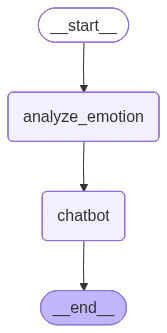

In [15]:
from typing import Optional
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_openai import ChatOpenAI

# MessagesState를 상속하여 커스텀 필드 추가
class GraphState(MessagesState):
    # 사용자의 감정 상태를 추적하는 필드 추가
    emotion: Optional[str] 

# LLM 인스턴스 생성
llm = ChatOpenAI(model="gpt-4.1-mini")

# 감정 분석을 위한 프롬프트 템플릿
EMOTION_PROMPT = """
사용자의 메시지를 분석하여 감정 상태를 파악해주세요.
가능한 감정 상태: 행복, 슬픔, 화남, 중립

사용자 메시지: {message}

감정 상태만 한 단어로 답변해주세요.
"""

# 감정 분석 노드
def analyze_emotion(state: GraphState) -> GraphState:
    # 가장 최근 사용자 메시지 가져오기
    last_message = state["messages"][-1].content
    
    # 감정 분석 실행
    emotion_analysis = llm.invoke(EMOTION_PROMPT.format(message=last_message))
    
    # 상태 업데이트
    return {
        "emotion": emotion_analysis.content.strip()
    }

# 챗봇 응답 노드
def chatbot(state: GraphState) -> GraphState:
    # 현재 감정 상태를 고려한 시스템 메시지 생성
    system_message = f"""
    사용자의 현재 감정 상태는 {state['emotion']}입니다.
    이를 고려하여 공감적이고 적절한 응답을 해주세요.
    """
    
    # 기존 메시지에 시스템 메시지 추가
    messages = [{"role": "system", "content": system_message}] + state["messages"]
    
    # LLM 응답 생성
    response = llm.invoke(messages)
    
    return {"messages": [response]}

# Workflow Graph 구성
builder = StateGraph(GraphState)

# 노드 추가
builder.add_node("analyze_emotion", analyze_emotion)
builder.add_node("chatbot", chatbot)

# 엣지 추가
builder.add_edge(START, "analyze_emotion")
builder.add_edge("analyze_emotion", "chatbot")
builder.add_edge("chatbot", END)

# 그래프 컴파일
graph = builder.compile()

# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
# 초기 상태
initial_state = {
    "messages": [{"role": "user", "content": "오늘 정말 힘든 하루였어요..."}]
}

# 그래프 실행
for event in graph.stream(initial_state, stream_mode="values"):
    if "emotion" in event:
        print(f"감정 상태: {event['emotion']}")
    if "messages" in event:
        print("메시지:")
        for msg in event["messages"]:
            print(f"{msg.type}: {msg.content}")
    print("-"*100)

메시지:
human: 오늘 정말 힘든 하루였어요...
----------------------------------------------------------------------------------------------------
감정 상태: 슬픔
메시지:
human: 오늘 정말 힘든 하루였어요...
----------------------------------------------------------------------------------------------------
감정 상태: 슬픔
메시지:
human: 오늘 정말 힘든 하루였어요...
ai: 정말 많이 힘드셨겠어요. 하루가 그렇게 지치게 느껴질 때는 누구나 힘들 수밖에 없죠. 혹시 어떤 일 때문에 그렇게 힘든 하루였는지 조금 더 이야기해 주실 수 있을까요? 함께 이야기 나누면서 조금이라도 위로가 되었으면 해요.
----------------------------------------------------------------------------------------------------


---

## **병렬 처리**

- **분기(branching)** 기능을 통해 LangGraph에서 노드의 병렬 실행이 가능

- 병렬 처리는 **독립적인 작업**들을 동시에 실행함으로써 전체 처리 시간을 단축

- 다양한 데이터 소스에서 **정보 수집 및 처리**가 필요한 경우 병렬 실행이 특히 효과적

`(1) 표준 엣지를 사용한 분기 (Fan-out/Fan-in)`

- **Fan-out** 구조는 하나의 노드에서 여러 병렬 노드로 데이터를 분산시키는 방식을 구현

- **Fan-in** 구조는 병렬로 처리된 여러 노드의 결과를 단일 노드에서 취합하는 역할

- 가장 기본적이고 직관적인 병렬 처리 구조

In [ ]:
# 여러 검색 엔진에서 정보 가져오기

import operator
from typing import Annotated, Any, TypedDict
from langgraph.graph import StateGraph, START, END

# 상태 정의: 검색 결과를 누적할 리스트를 포함
class SearchState(TypedDict):
    search_results: Annotated[list, operator.add]

# 각 검색 엔진에 대한 노드 정의
def search_engine_a(state: SearchState):
    print("Searching with Engine A...")
    return {"search_results": ["Result A1", "Result A2"]}

def search_engine_b(state: SearchState):
    print("Searching with Engine B...")
    return {"search_results": ["Result B1"]}

def combine_results(state: SearchState):
    print("Combining search results...")
    return {"search_results": ["Combined Result"]}

# 그래프 구성
search_builder = StateGraph(SearchState)
search_builder.add_node("engine_a", search_engine_a)
search_builder.add_node("engine_b", search_engine_b)
search_builder.add_node("combine", combine_results)

# 엣지 연결: START -> engine_a, engine_b (병렬 실행) -> combine -> END
search_builder.add_edge(START, "engine_a")
search_builder.add_edge(START, "engine_b")
search_builder.add_edge("engine_a", "combine")
search_builder.add_edge("engine_b", "combine")
# search_builder.add_edge(["engine_a", "engine_b"], "combine") # 병렬 실행 후 결과 결합
search_builder.add_edge("combine", END)

# 그래프 컴파일
search_graph = search_builder.compile()

# 그래프 시각화
display(Image(search_graph.get_graph().draw_mermaid_png()))

In [ ]:
# 그래프 실행
search_graph.invoke({"search_results": []})

`(2) 조건부 엣지를 사용한 분기 (Conditional Branching)`

**구현 예시**

- 초기 그리팅 후 조건부로 서비스를 실행
- 선택된 서비스들을 병렬로 실행
- 모든 서비스 실행 후 최종 처리를 수행
- 전체 과정의 상태를 추적

In [ ]:
import operator
from typing import Annotated, Sequence, TypedDict
from langgraph.graph import StateGraph, START, END

# 상태 정의: aggregate 리스트와 라우팅을 위한 user_intent 필드 포함
class ChatState(TypedDict):
    messages: Annotated[list, operator.add]  # aggregate 대신 messages 사용
    user_intent: str  # 라우팅 조건

# 서비스 노드 정의
def greet_service(state: ChatState):
    print(f'Adding "greet" to {state["messages"]}')
    return {"messages": ["Hello!"]} 

def weather_service(state: ChatState):
    print(f'Adding "weather" to {state["messages"]}')
    return {"messages": ["The weather is sunny."]}

def news_service(state: ChatState):
    print(f'Adding "news" to {state["messages"]}')
    return {"messages": ["Here's the latest news."]}

def help_service(state: ChatState):
    print(f'Adding "help" to {state["messages"]}')
    return {"messages": ["How can I help you?"]}

def process_response(state: ChatState):
    print(f'Adding "process" to {state["messages"]}')
    return {"messages": ["Processing complete."]}

# 라우팅 함수: user_intent 값에 따라 서비스 노드 결정
def route_services(state: ChatState) -> Sequence[str]:
    if state["user_intent"] == "weather_news":
        # 날씨와 뉴스 서비스를 병렬 실행
        return ["weather_service", "news_service"]
    
    # 기본적으로 인사와 뉴스 서비스를 병렬 실행
    return ["help_service", "news_service"]

# 그래프 구성
chat_builder = StateGraph(ChatState)

# 노드 추가
chat_builder.add_node("greet", greet_service)
chat_builder.add_node("weather_service", weather_service)
chat_builder.add_node("news_service", news_service)
chat_builder.add_node("help_service", help_service)
chat_builder.add_node("process", process_response)

# 엣지 추가
chat_builder.add_edge(START, "greet")

# 중간 노드 정의
intermediates = ["weather_service", "news_service", "help_service"]

# greet 노드에서 조건부 엣지 추가
chat_builder.add_conditional_edges(
    "greet",
    route_services,
    intermediates,
)

# 중간 노드들을 process 노드에 연결
for node in intermediates:
    chat_builder.add_edge(node, "process")

chat_builder.add_edge("process", END)

# 그래프 컴파일
chat_graph = chat_builder.compile()

# 그래프 시각화
display(Image(chat_graph.get_graph().draw_mermaid_png()))

In [ ]:
# "weather_news" 의도를 가지고 실행
chat_graph.invoke({"messages": [], "user_intent": "weather_news"})

In [ ]:
# 다른 의도를 가지고 실행
chat_graph.invoke({"messages": [], "user_intent": "news"})

`(3) 다단계 분기 (Multi-step Parallel Paths)`

- **다단계 분기**는 각각의 병렬 경로에서 여러 단계의 독립적인 처리를 지원 

- 각 분기는 **서로 다른 데이터 처리 파이프라인**을 포함할 수 있어, 복잡한 워크플로우 구현이 가능

- 최종적으로 각 분기의 결과는 하나의 노드에서 **통합되어 처리**될 수 있음 

In [ ]:
# 데이터 전처리와 모델 예측을 병렬로 수행하기

import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END

class ModelState(TypedDict):
    data: Annotated[list, operator.add]

def fetch_data_a(state: ModelState):
    return {"data": ["Data A1"]}

def preprocess_data_a(state: ModelState):
    return {"data": ["Preprocessed A1"]}

def fetch_data_b(state: ModelState):
    return {"data": ["Data B1"]}

def make_prediction(state: ModelState):
    return {"data": ["Prediction from A and B"]}

model_builder = StateGraph(ModelState)
model_builder.add_node("fetch_a", fetch_data_a)
model_builder.add_node("preprocess_a", preprocess_data_a)
model_builder.add_node("fetch_b", fetch_data_b)
model_builder.add_node("predict", make_prediction)

model_builder.add_edge(START, "fetch_a")
model_builder.add_edge(START, "fetch_b")
model_builder.add_edge("fetch_a", "preprocess_a")
model_builder.add_edge(["preprocess_a", "fetch_b"], "predict")
model_builder.add_edge("predict", END)

model_graph = model_builder.compile()

display(Image(model_graph.get_graph().draw_mermaid_png()))

In [ ]:
# 그래프 실행
model_graph.invoke({"data": []})

`(4) 동적 엣지 생성 및 개별 상태 전달하기 (Map-Reduce 패턴)`

- **기본 동작의 한계**

    - 기본적으로 LangGraph의 노드와 엣지는 미리 정의되며, 모든 노드는 동일한 공유 상태(shared state)를 사용함. 하지만 다음과 같은 경우에는 문제가 발생할 수 있음. 

    -  **동적 엣지:** 실행 시점에 따라 연결해야 할 노드의 수가 달라지는 경우 (예: 입력 데이터에 따라 다른 개수의 하위 작업을 생성해야 하는 경우)
    -  **개별 상태:** 각 노드가 독립적인 상태를 가지고 작업해야 하는 경우 (예: 각 하위 작업이 서로 다른 데이터를 처리해야 하는 경우)

- **Map-Reduce 패턴**

    1.  **Map:**  하나의 노드(mapper)가 여러 개의 객체(또는 작업)를 생성
    2.  **Reduce:** 다른 노드(reducer)가 mapper가 생성한 객체들을 처리하고 결과를 결합

-  **`Send` 객체**

    - LangGraph에서는 `Send` 객체를 사용하여 map 단계를 구현할 수 있음 
    - `Send` 객체는 조건부 엣지(`add_conditional_edges`)의 `condition_function`에서 반환될 수 있으며, 다음과 같은 두 가지 인수를 받아서 구현

        1.  **`node_name` (str):**  실행할 노드의 이름
        2.  **`state` (dict):** 해당 노드에 전달할 개별 상태

In [ ]:
import operator
from typing import Annotated, List, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from IPython.display import Image, display

# 글로벌 상태 정의
class WebScrapingState(TypedDict):
    urls: List[str]  # 스크래핑할 URL 목록 (글로벌)
    scraped_data: Annotated[List[dict], operator.add]  # 스크래핑된 데이터 (글로벌, 누적)

# 로컬 상태 정의
class PrivateSate(TypedDict):
    url: str  # 스크래핑할 URL (로컬 상태)

# 노드 정의
def define_urls(state: WebScrapingState):
    """URL 목록을 정의합니다. (글로벌 상태 사용)"""
    print("Using provided URLs...")
    return {"urls": state["urls"]}  # 글로벌 상태(urls) 사용

def scrape_website(state: PrivateSate):  # 로컬 상태를 받음
    """각 웹사이트를 스크래핑합니다. (로컬 상태 사용)"""
    print(f"Scraping {state['url']}...")  # 로컬 상태(url) 사용
    # 실제 스크래핑 로직 (여기서는 시뮬레이션)
    return {"scraped_data": [f"Data from {state['url']}"]} # 글로벌 상태(scraped_data) 사용

def route_to_scraping(state: WebScrapingState):
    """스크래핑 노드로 라우팅합니다. (글로벌 상태 사용, 로컬 상태 생성)"""
    # 글로벌 상태(urls)를 사용하여 로컬 상태({"url": url})를 생성하고 Send로 전달
    return [Send("scrape_website", {"url": url}) for url in state["urls"]]


# 그래프 구성
graph = StateGraph(WebScrapingState)  
graph.add_node("define_urls", define_urls)
graph.add_node("scrape_website", scrape_website)

graph.set_entry_point("define_urls")

graph.add_conditional_edges(
    "define_urls",
    route_to_scraping,
    ["scrape_website"],  # 스크래핑 노드로 라우팅
)

graph.add_edge("scrape_website", END)

# 그래프 컴파일
compiled_graph = graph.compile()

# 그래프 시각화
display(Image(compiled_graph.get_graph().draw_mermaid_png()))  

In [ ]:
# 그래프 실행 (외부에서 URL 목록 입력)
initial_state = {"urls": ["https://example.com", "https://example.net", "https://example.org"]}
result = compiled_graph.invoke(initial_state)

```mermaid
graph LR
    define_urls[define_urls]
    scrape_website[scrape_website]
    _start((START)) --> define_urls
    define_urls --"Send(scrape_website)"--> scrape_website
    scrape_website --> _end((END))

```

In [ ]:
pprint(result)

### **`Send` 객체의 사용 예시**

- 문서 요약 시스템 (대용량 텍스트 처리)
- 긴 문서를 여러 부분으로 나누어 병렬로 요약한 후 통합하는 시스템

In [ ]:
import operator
from typing import Annotated, List, Dict, Tuple, Any
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langgraph.types import Send
from langgraph.graph import END, START, StateGraph
from langchain_openai import ChatOpenAI  
from IPython.display import Image, display

# LLM 모델 초기화
model = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

class SummarizationState(TypedDict):
    contents: List[Document]  # 초기 Document 객체 리스트
    chunks: List[Dict[str, Any]]  # 청크 리스트 (인덱스, 내용, 메타데이터 포함)
    summaries: Annotated[List[Tuple[int, str]], operator.add]  # (인덱스, 요약) 튜플 리스트
    final_summary: str

class DocumentState(TypedDict):
    content: str
    index: int  # 청크의 순서를 나타내는 인덱스

def split_documents(state: SummarizationState):
    """각 Document를 순서를 유지하며 청크로 분할"""
    chunks = []
    chunk_size = 1000
    global_chunk_index = 0
    
    # 각 Document를 순차적으로 처리
    for doc_index, document in enumerate(state["contents"]):
        content = document.page_content
        
        # 해당 문서를 청크로 분할
        for i in range(0, len(content), chunk_size):
            chunk_content = content[i:i + chunk_size]
            
            # 빈 청크는 스킵
            if chunk_content.strip():
                chunks.append({
                    "index": global_chunk_index,
                    "content": chunk_content,
                    "source_document": doc_index,
                    "source_metadata": document.metadata
                })
                global_chunk_index += 1
    
    return {"chunks": chunks}

def summarize_document(state: DocumentState):
    """개별 문서 청크를 요약"""
    prompt = f"""다음 텍스트를 2-3문장으로 간결하게 요약해주세요:
    
    {state['content']}
    """
    
    try:
        response = model.invoke(prompt)
        summary = response.content
    except Exception as e:
        summary = f"요약 생성 중 오류 발생: {str(e)}"
    
    # 순서 정보와 함께 요약 반환
    return {"summaries": [(state["index"], summary)]}

def continue_to_summarization(state: SummarizationState):
    """각 청크를 병렬로 요약하도록 Send 작업 생성"""
    return [
        Send("summarize_document", {
            "content": chunk["content"],
            "index": chunk["index"]
        }) 
        for chunk in state["chunks"]
    ]

def create_final_summary(state: SummarizationState):
    """순서를 유지하며 최종 요약 생성"""
    # 인덱스별로 요약을 정렬
    sorted_summaries = sorted(state["summaries"], key=lambda x: x[0])
    
    # 순서대로 요약들을 결합
    ordered_summaries = [summary for _, summary in sorted_summaries]
    combined_summaries = "\n\n".join(ordered_summaries)
    
    prompt = f"""다음은 문서를 청크별로 요약한 내용들입니다. 
    이들을 종합하여 하나의 포괄적이고 일관성 있는 최종 요약을 작성해주세요.
    원본 문서의 순서와 흐름을 유지하면서 핵심 내용을 간결하게 정리해주세요:
    
    {combined_summaries}
    
    최종 요약:
    """
    
    try:
        response = model.invoke(prompt)
        final_summary = response.content
    except Exception as e:
        final_summary = f"최종 요약 생성 중 오류 발생: {str(e)}"
    
    return {"final_summary": final_summary}

# 그래프 구성
builder = StateGraph(SummarizationState)
builder.add_node("split_documents", split_documents)
builder.add_node("summarize_document", summarize_document)
builder.add_node("create_final_summary", create_final_summary)

# 엣지 연결
builder.add_edge(START, "split_documents")
builder.add_conditional_edges("split_documents", continue_to_summarization, ["summarize_document"])
builder.add_edge("summarize_document", "create_final_summary")
builder.add_edge("create_final_summary", END)

# 그래프 컴파일
graph = builder.compile()

# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("data/labor_law.pdf")
documents = loader.load()

print(f"로드된 페이지 수: {len(documents)}")

In [ ]:
# PDF 문서 요약 실행
initial_state = {
    "contents": documents,
}
    
for step in graph.stream(initial_state, stream_mode="values"):
    if "chunks" in step:
        print(f"처리 중인 청크 수: {len(step['chunks'])}")
    if "summaries" in step:
        print(f"현재까지 생성된 요약 수: {len(step['summaries'])}")
    if "final_summary" in step:
        print("최종 요약 생성 중...")
        print(step["final_summary"])  # 최종 요약 출력
    print("-"*100)

In [ ]:
# 최종 상태 출려
print("최종 상태:")
print("최종 요약:", step.get("final_summary", "요약이 생성되지 않았습니다."))
print("전체 청크 수:", len(step.get("chunks", [])))
print("전체 요약 수:", len(step.get("summaries", [])))
print("전체 문서 수:", len(step.get("contents", [])))